# Phase I: Isolated scenario

**Building:** Linear Building · **Model:** `models/linear_isolated.idf` · **Weather:** `weather/BRA_RS_Passo.Fundo.869630_TMYx.2007-2021.epw` · **Output:** `results/linear_isolated_orientation_results.csv`

Multi-objective optimization (NSGA-II via BESOS) minimizing cooling and heating demand with a single decision variable (building orientation, EnergyPlus `North Axis`, 0–359°). Run this notebook from its own folder (paths are relative to `notebooks/`).

## Running the evaluations for the optimization


### *Import* of libraries

In [1]:
from besos import eppy_funcs as ef
from besos import eplus_funcs as ep
from besos.problem import EPProblem
from besos.objectives import *
from besos.evaluator import EvaluatorEP
from besos.parameters import wwr, RangeParameter, FieldSelector, FilterSelector, GenericSelector, Parameter, expand_plist
from besos.optimizer import NSGAII, SPEA2
from platypus.evaluator import MapEvaluator
import platypus
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from dask.distributed import Client

### Simulation model

In [2]:
building = ef.get_building('../models/linear_isolated.idf') # Loading the E+ model;

### Variables of the multi-objective analysis

In [3]:
parameters = []

parameters.append(
            Parameter(
                selector=FieldSelector(
                    class_name="BUILDING",             # Class of E+;
                    object_name="RosaBrasil",    # Object name;
                    field_name="North Axis", # Object field;
                ),
                name='Orientation',
                value_descriptor=RangeParameter(min_val=0, max_val=359)      # Range
                )
            )

### Selection of the analysis objectives

In [4]:
demanda_resf = MeterReader('DistrictCooling:HVAC', name="Cooling demand (kWh/m²)")
demanda_aquec = MeterReader('DistrictHeating:HVAC', name="Heating demand (kWh/m²)")
EPobjectives = [demanda_resf,demanda_aquec] # cooling and heating as objectives;
problem = EPProblem(parameters, EPobjectives)  # Creating an instance of the problem;

### NSGA-II evaluation function and parameters definition + runtime

In [5]:
evaluator = EvaluatorEP(problem, building, epw="../../../weather/BRA_RS_Passo.Fundo.869630_TMYx.2007-2021.epw")   # Evaluation function with the problem and the model;
startTime = datetime.now()
results = NSGAII(evaluator, evaluations=200, population_size=100)   # running the NSGA-II;
print(datetime.now() - startTime)

8:33:49.103035


### Results

In [6]:
results

,Orientation,Cooling demand (kWh/m²),Heating demand (kWh/m²),violation,pareto-optimal
0,180.160620,1.972312e+11,7.552876e+10,0,True
1,358.905285,2.080428e+11,6.825089e+10,0,True
2,4.125739,1.983949e+11,7.493444e+10,0,True
3,0.963548,1.979254e+11,7.499862e+10,0,True
4,183.973680,1.976257e+11,7.544539e+10,0,True
...,...,...,...,...,...
95,216.232224,2.399070e+11,7.950011e+10,0,False
96,149.477871,2.416015e+11,7.321129e+10,0,False
97,328.715892,2.430970e+11,7.298480e+10,0,False
98,216.440543,2.402548e+11,7.953714e+10,0,False


### *Plot* of the results (heating and cooling demand in kWh/m²·year)

In [7]:
import math
results['Heating demand (kWh/m²)'] = (results['Heating demand (kWh/m²)']*pow(10,-9))
results['Cooling demand (kWh/m²)'] = (results['Cooling demand (kWh/m²)']*pow(10,-9))
results['Heating demand (kWh/m²)'] = (results['Heating demand (kWh/m²)']/0.0036)
results['Cooling demand (kWh/m²)'] = (results['Cooling demand (kWh/m²)']/0.0036)
results['Heating demand (kWh/m²)'] = (results['Heating demand (kWh/m²)']/884.00)
results['Cooling demand (kWh/m²)'] = (results['Cooling demand (kWh/m²)']/884.00)

results

,Orientation,Cooling demand (kWh/m²),Heating demand (kWh/m²),violation,pareto-optimal
0,180.160620,61.975627,23.733271,0,True
1,358.905285,65.372927,21.446357,0,True
2,4.125739,62.341291,23.546519,0,True
3,0.963548,62.193762,23.566687,0,True
4,183.973680,62.099592,23.707072,0,True
...,...,...,...,...,...
95,216.232224,75.385566,24.981181,0,False
96,149.477871,75.918015,23.005054,0,False
97,328.715892,76.387955,22.933887,0,False
98,216.440543,75.494838,24.992816,0,False


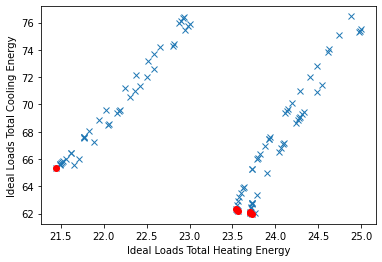

In [8]:
optres = results.loc[results['pareto-optimal']==True,:] # pareto-optimal
plt.plot(results['Heating demand (kWh/m²)'], results['Cooling demand (kWh/m²)'],'x') # Plot all results in 'x'
plt.plot(optres['Heating demand (kWh/m²)'], optres['Cooling demand (kWh/m²)'],'ro') # Plot of the best solutions in red
plt.xlabel('Ideal Loads Total Heating Energy')
plt.ylabel('Ideal Loads Total Cooling Energy')
plt.savefig("../results/linear_isolated_orientation_pareto.png")
#plt.axis([0.00,0.08,0.0,1.6]) #Set the dimension of the chart

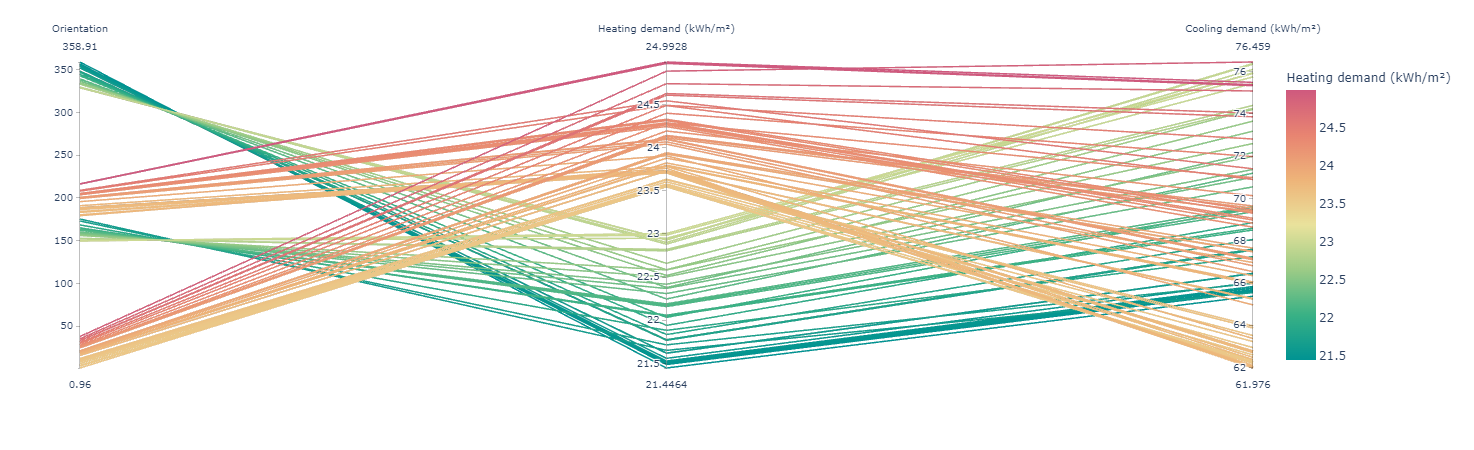

In [9]:
import plotly
plotly.offline.init_notebook_mode(connected=True)
import plotly.express as px
fig = px.parallel_coordinates(results,color="Heating demand (kWh/m²)", dimensions=["Orientation","Heating demand (kWh/m²)","Cooling demand (kWh/m²)"],
    color_continuous_scale=px.colors.diverging.Temps)
fig.show()

In [10]:
optres

,Orientation,Cooling demand (kWh/m²),Heating demand (kWh/m²),violation,pareto-optimal
0,180.160620,61.975627,23.733271,0,True
1,358.905285,65.372927,21.446357,0,True
2,4.125739,62.341291,23.546519,0,True
3,0.963548,62.193762,23.566687,0,True
4,183.973680,62.099592,23.707072,0,True
5,3.142914,62.265664,23.549315,0,True
6,182.963739,62.027548,23.709658,0,True


In [11]:
results.to_csv('../results/linear_isolated_orientation_results.csv')

In [12]:
min_idealloads = results['Cooling demand (kWh/m²)']+results['Heating demand (kWh/m²)']
min_idealloads = min_idealloads[min_idealloads == min_idealloads.min()]
bestone = results[(results['Cooling demand (kWh/m²)']+results['Heating demand (kWh/m²)']) == min_idealloads.min()]
bestone

,Orientation,Cooling demand (kWh/m²),Heating demand (kWh/m²),violation,pareto-optimal
0,180.16062,61.975627,23.733271,0,True
